In [68]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
data = pd.read_csv("co2.csv")

In [69]:
data.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [70]:
X = data[[
    "Engine Size(L)",
    "Fuel Consumption City (L/100 km)", "Cylinders", "Fuel Consumption Hwy (L/100 km)", "Fuel Consumption Comb (L/100 km)", ]].values

y = data["CO2 Emissions(g/km)"].values


In [71]:
mu = X.mean(axis=0)
sigma = X.std(axis=0)

X = (X - mu) / sigma
m = len(X)
X_b = np.c_[np.ones(m), X]

In [72]:
def compute_cost(X, y, theta):
    m = len(y)
    predictions = X.dot(theta)
    return (1 / (2 * m)) * np.sum((predictions - y) ** 2)

In [73]:
def gradient_descent(X, y, theta, alpha, epochs):
    m = len(y)
    losses = []

    for _ in range(epochs):
        predictions = X.dot(theta)
        error = predictions - y

        gradients = (1 / m) * X.T.dot(error)
        theta = theta - alpha * gradients

        loss = (1 / (2 * m)) * np.sum(error ** 2)
        losses.append(loss)

    return theta, losses

In [74]:
theta = np.zeros(X_b.shape[1])
alpha = 0.01
epochs = 700

theta, losses = gradient_descent(X_b, y, theta, alpha, epochs)
print("Theta:", theta)
print("loss:", compute_cost(X_b, y, theta))
print("loss before:", losses[0])
print("loss after:", losses[-1])

Theta: [250.3641062    9.3370362   13.42681154  10.90372717  11.49963124
  12.94372584]
loss: 207.246344356134
loss before: 33107.980636425185
loss after: 207.2473624296813


In [75]:
x_new = np.array([[2.0, 9.5, 6, 7, 8.5]])
x_new_norm = (x_new - mu) / sigma
x_new_b = np.c_[np.ones(1), x_new_norm]

y_pred = x_new_b.dot(theta)
print("Predicted CO2:", y_pred[0])


Predicted CO2: 211.30339481721248


In [76]:
corr = data.corr(numeric_only=True)
print(corr["CO2 Emissions(g/km)"].sort_values(ascending=False))


CO2 Emissions(g/km)                 1.000000
Fuel Consumption City (L/100 km)    0.919592
Fuel Consumption Comb (L/100 km)    0.918052
Fuel Consumption Hwy (L/100 km)     0.883536
Engine Size(L)                      0.851145
Cylinders                           0.832644
Fuel Consumption Comb (mpg)        -0.907426
Name: CO2 Emissions(g/km), dtype: float64


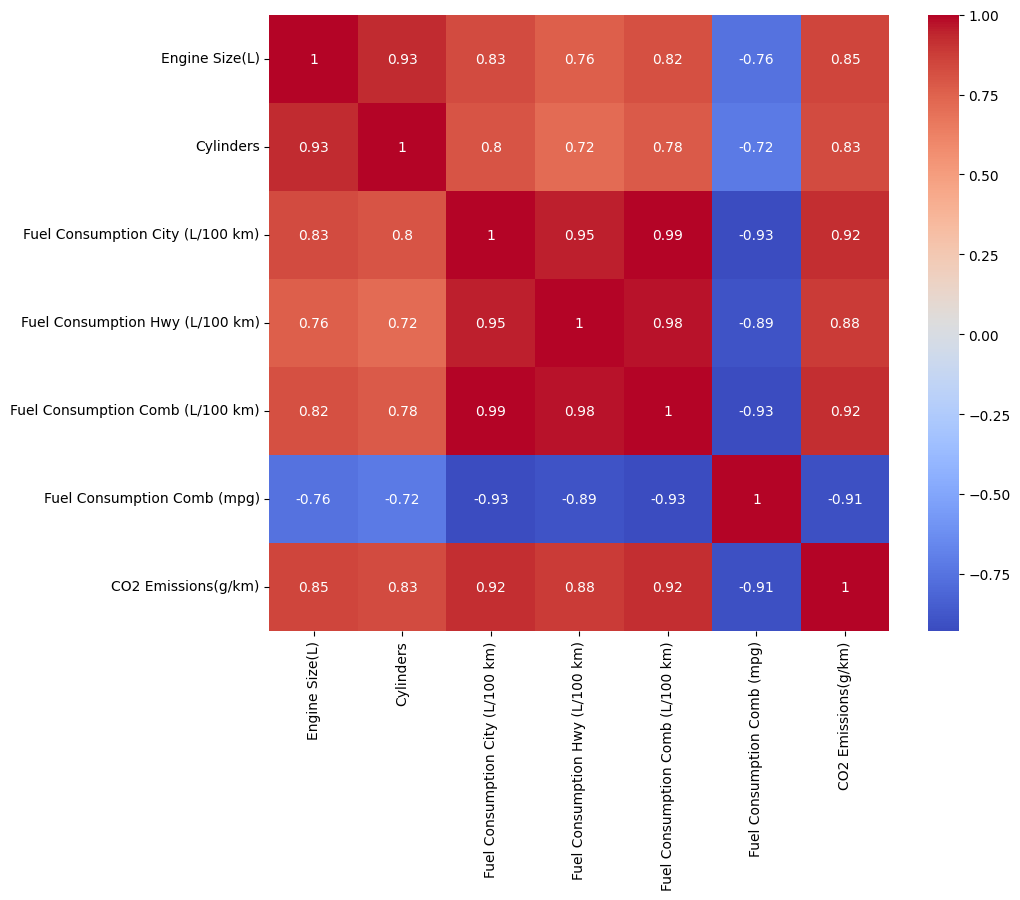

In [77]:
corr = data.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()
